In [1]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 6.3 MB/s eta 0:00:00


In [2]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF

import torch
import torch.nn as nn
import torch.nn.functional as nf
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [3]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.19MB/s]


In [6]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [7]:
data, targets = next(iter(train_loader))

In [8]:
data1, targets1 = next(iter(test_loader))

torch.Size([128, 1, 28, 28])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.

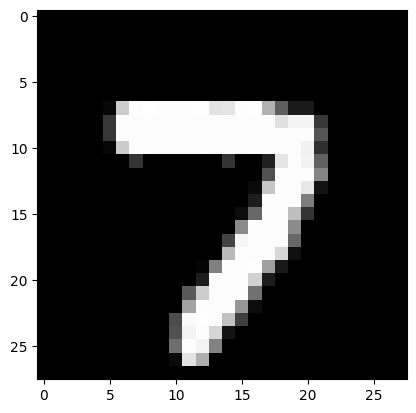

In [9]:
print(data.shape)
print(data[0])
print(data[0]*255)
plt.imshow(data[0].squeeze(),cmap='gray')
plt.show()

In [10]:
# Network Architecture
input_neurons_per_class = 10
num_inputs = 28*28*input_neurons_per_class
num_hidden = 1000
num_outputs = 10
neurons_per_class = 50
pop_outputs = num_outputs * neurons_per_class
# Temporal Dynamics
num_steps = 25
beta = 0.95
spike_grad = surrogate.fast_sigmoid(slope=25)


In [11]:
from snntorch import spikegen

spike_data = spikegen.rate(data, num_steps=num_steps)

print(spike_data.shape)
print(spike_data[:,0,0,:,:])

torch.Size([25, 128, 1, 28, 28])
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0.

In [12]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Input is now 7840 instead of 784
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # Output uses population decoding (500 outputs)
        self.fc2 = nn.Linear(num_hidden, pop_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        # Initialize hidden states
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

net = Net().to(device)

In [13]:
# 1. Flatten the incoming batch if it isn't already (from [batch_size, 1, 28, 28] to [batch_size, 784])
data_flattened = data.view(data.size(0), -1)

# 2. Replicate each pixel value 10 times for the input population
# .unsqueeze(-1) changes shape to [batch_size, 784, 1]
# .repeat(1, 1, input_neurons_per_class) changes shape to [batch_size, 784, 10]
# .view(data.size(0), -1) flattens it to [batch_size, 7840]
data_pop = data_flattened.unsqueeze(-1).repeat(1, 1, input_neurons_per_class).view(data.size(0), -1)

# 3. Generate independent Poisson spikes for all 7,840 neurons across your time steps
spike_data = spikegen.rate(data_pop, num_steps=num_steps).to(device)

# 4. Pass the population-encoded spikes into your updated network
spk_rec1, mem_rec = net(spike_data)

# This will print: torch.Size([25, batch_size, 500])
# (Since num_steps=25 and pop_outputs = 10 classes * 50 neurons = 500)
print(spk_rec1.shape)

torch.Size([25, 128, 500])


In [14]:
loss_fn = SF.mse_count_loss(correct_rate=1.0, incorrect_rate=0.0, population_code=True, num_classes=10)
optimizer = torch.optim.Adam(net.parameters(), lr=2e-3, betas=(0.9, 0.999))

In [15]:
from snntorch import utils
for data, targets in train_loader:
    data = data.to(device)       # Shape: [batch_size, 1, 28, 28]
    targets = targets.to(device) # Shape: [batch_size]
    # 4. Reset network states and forward pass
    snn.utils.reset(net)
    spk_rec, _ = net(spike_data)

    # 5. Compute loss and optimize (using population-coded loss)
    loss_val = loss_fn(spk_rec, targets)
    optimizer.zero_grad()
    loss_val.backward()
    optimizer.step()
    acc = SF.accuracy_rate(
    spk_rec1,
    targets,
    population_code=True,
    num_classes=10
    )

In [16]:
print(loss_val.item())
print(acc*100)

5624.0693359375
11.71875


In [17]:
from snntorch import utils

def batch_accuracy(loader, net, num_steps):

    with torch.no_grad():
        total = 0
        acc = 0

        net.eval()

        for data, targets in loader:

            # 1. Flatten original images to shape [batch_size, 784]
            data_flattened = data.view(data.size(0), -1)

            # 2. Duplicate each pixel 10 times to shape [batch_size, 7840]
            data_pop = data_flattened.unsqueeze(-1).repeat(1, 1, 10).view(data.size(0), -1)

            # 3. Convert images to population-encoded spike trains [num_steps, batch_size, 7840]
            spike_data = spikegen.rate(
                data_pop,
                num_steps=num_steps
            ).to(device)

            targets = targets.to(device)

            # Reset hidden states
            utils.reset(net)

            # Forward pass (outputs spikes of shape [num_steps, batch_size, 500])
            spk_rec, _ = net(spike_data)

            # Population accuracy calculation (looks across the 500 outputs grouped into 10 classes)
            acc += SF.accuracy_rate(
                spk_rec,
                targets,
                population_code=True,
                num_classes=10
            ) * spk_rec.size(1)

            total += spk_rec.size(1)

    return acc / total

In [18]:
print(next(net.parameters()).device)

cuda:0


In [19]:
test_acc = batch_accuracy(test_loader, net, num_steps)

print(test_acc * 100)

10.096153846153847


In [20]:
targets = targets.to(device)

loss_val = loss_fn(spk_rec1, targets)

acc = SF.accuracy_rate(
    spk_rec1,
    targets,
    population_code=True,
    num_classes=10
)

In [21]:
num_epochs = 15
loss_hist = []
test_acc_hist = []
counter = 0

for epoch in range(num_epochs):

    for data, targets in train_loader:

        # Move targets to device
        targets = targets.to(device)

        # 1. Flatten the incoming images [batch_size, 1, 28, 28] -> [batch_size, 784]
        data_flattened = data.view(data.size(0), -1)

        # 2. Replicate each pixel 10 times to get 10 neurons per input -> [batch_size, 7840]
        data_pop = data_flattened.unsqueeze(-1).repeat(1, 1, 10).view(data.size(0), -1)

        # 3. Generate independent Poisson spikes and push to device -> [num_steps, batch_size, 7840]
        spike_data = spikegen.rate(
            data_pop,
            num_steps=num_steps
        ).to(device)

        utils.reset(net)

        spk_rec, _ = net(spike_data)

        loss_val = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        loss_hist.append(loss_val.item())

        if counter % 50 == 0:

            with torch.no_grad():

                net.eval()

                test_acc = batch_accuracy(
                    test_loader,
                    net,
                    num_steps
                )

                print(f"Iteration {counter}, Test Acc: {test_acc*100:.2f}%")

                # If test_acc is already a regular python float/tensor, you can use .item() safely
                # (or just test_acc if batch_accuracy returns a float directly)
                try:
                    test_acc_hist.append(test_acc.item())
                except AttributeError:
                    test_acc_hist.append(test_acc)

                net.train()

        counter += 1

Iteration 0, Test Acc: 10.11%
Iteration 50, Test Acc: 10.16%
Iteration 100, Test Acc: 28.37%
Iteration 150, Test Acc: 38.48%
Iteration 200, Test Acc: 52.60%
Iteration 250, Test Acc: 69.89%
Iteration 300, Test Acc: 85.10%
Iteration 350, Test Acc: 88.17%
Iteration 400, Test Acc: 88.41%
Iteration 450, Test Acc: 90.06%
Iteration 500, Test Acc: 89.96%
Iteration 550, Test Acc: 91.32%
Iteration 600, Test Acc: 91.27%
Iteration 650, Test Acc: 91.84%
Iteration 700, Test Acc: 92.32%
Iteration 750, Test Acc: 92.56%
Iteration 800, Test Acc: 92.07%
Iteration 850, Test Acc: 92.75%
Iteration 900, Test Acc: 92.17%
Iteration 950, Test Acc: 92.47%
Iteration 1000, Test Acc: 92.62%
Iteration 1050, Test Acc: 93.10%
Iteration 1100, Test Acc: 93.43%
Iteration 1150, Test Acc: 93.14%
Iteration 1200, Test Acc: 92.59%
Iteration 1250, Test Acc: 93.68%
Iteration 1300, Test Acc: 93.64%
Iteration 1350, Test Acc: 93.44%
Iteration 1400, Test Acc: 93.68%
Iteration 1450, Test Acc: 93.42%
Iteration 1500, Test Acc: 93.59%


KeyboardInterrupt: 

original no 7
predicted no 7


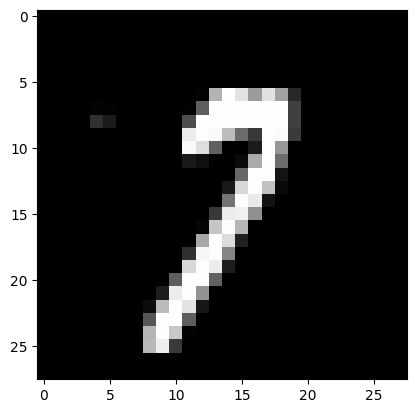

tensor([[[0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0',
       grad_fn=<StackBackward0>)


In [22]:
n = 13

# 1. Pick one image (keeps shape [1, 1, 28, 28])
single_img = data1[n].unsqueeze(0)
target = targets1[n].to(device)

# 2. Flatten the single image -> [1, 784]
data_flattened = single_img.view(1, -1)

# 3. Duplicate each pixel 10 times for the input population -> [1, 7840]
data_pop = data_flattened.unsqueeze(-1).repeat(1, 1, 10).view(1, -1)

# 4. Convert to independent Poisson spike train and move to device -> [25, 1, 7840]
spike_img = spikegen.rate(data_pop, num_steps=num_steps).to(device)

# Forward pass (outputs spikes of shape [25, 1, 500])
s, m = net(spike_img)

# Population decoding
s_sum = s.sum(dim=0)                          # Sum over time dimension -> [1, 500]
pop_activity = s_sum.view(1, num_outputs, neurons_per_class) # Reshape -> [1, 10, 50]
class_activity = pop_activity.sum(dim=2)      # Sum the 50 neurons per class -> [1, 10]
pc = class_activity.argmax(dim=1)             # Find the class index with the highest spikes

print("original no", target.item())
print("predicted no", pc.item())

# Plot the original 2D image correctly (using the original single_img before flattening)
plt.imshow(single_img.squeeze(), cmap="gray")
plt.show()

print(s)

In [25]:
wrong_imgs = []
wrong_preds = []
wrong_labels = []

net.eval()

with torch.no_grad():

    for data, targets in test_loader:

        # 1. Immediately move original batch and targets to your GPU (device)
        data = data.to(device)
        targets = targets.to(device)

        # 2. Flatten original images on the device -> [batch_size, 784]
        data_flattened = data.view(data.size(0), -1)

        # 3. Duplicate each pixel 10 times on the device -> [batch_size, 7840]
        data_pop = data_flattened.unsqueeze(-1).repeat(1, 1, 10).view(data.size(0), -1)

        # 4. Convert batch to population-encoded spike train directly on the device
        spike_data = spikegen.rate(data_pop, num_steps=num_steps)

        # Forward pass (outputs spikes of shape [25, batch_size, 500])
        spk_rec, mem_rec = net(spike_data)

        # Sum spikes over time -> [batch_size, 500]
        spk_sum = spk_rec.sum(dim=0)

        # Group 50 neurons per class -> [batch_size, 10, 50]
        pop_activity = spk_sum.view(-1, num_outputs, neurons_per_class)

        # Total activity of each class -> [batch_size, 10]
        class_activity = pop_activity.sum(dim=2)

        # Predicted digit -> [batch_size]
        preds = class_activity.argmax(dim=1)

        # Find wrong predictions
        wrong = preds != targets

        # Store the original unflattened images, predictions, and labels (moved to CPU for history lists)
        wrong_imgs.extend(data[wrong].cpu())
        wrong_preds.extend(preds[wrong].cpu())
        wrong_labels.extend(targets[wrong].cpu())

print("Total wrong predictions:", len(wrong_imgs))

Total wrong predictions: 500


Actual : 3
Predicted : 8


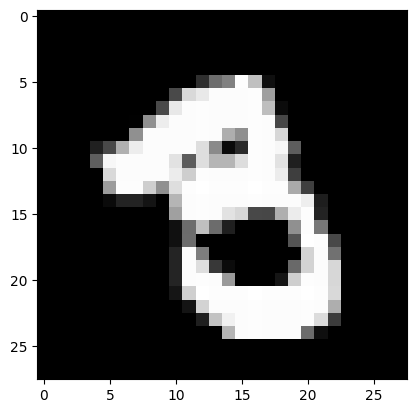

In [35]:
n = 53
plt.imshow(wrong_imgs[n].squeeze(), cmap='gray')

print("Actual :", wrong_labels[n].item())
print("Predicted :", wrong_preds[n].item())

plt.show()

In [32]:
from collections import Counter

wrong_pairs = Counter()

for actual, pred in zip(wrong_labels, wrong_preds):
    wrong_pairs[(actual.item(), pred.item())] += 1

print(wrong_pairs.most_common(20))

[((9, 4), 29), ((7, 2), 22), ((5, 8), 20), ((3, 2), 18), ((4, 9), 18), ((1, 8), 17), ((5, 6), 17), ((3, 8), 17), ((9, 8), 16), ((2, 8), 13), ((3, 5), 13), ((5, 3), 12), ((7, 9), 12), ((8, 3), 11), ((9, 3), 11), ((4, 6), 11), ((9, 0), 10), ((8, 6), 10), ((2, 7), 10), ((9, 7), 9)]
